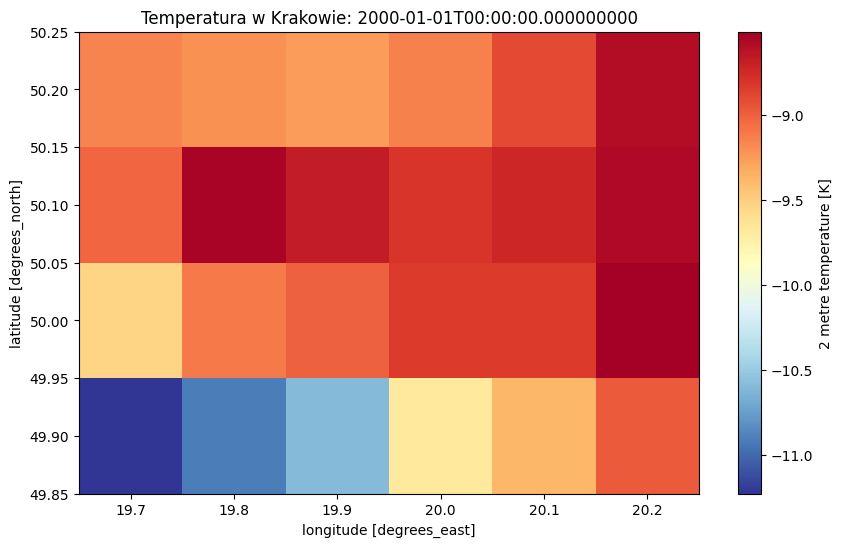

Wymiary Twoich danych: (4, 6)
Szerokość geograficzna (lat): [50.2 50.1 50.  49.9]
Długość geograficzna (lon): [19.7 19.8 19.9 20.  20.1 20.2]


In [3]:
import xarray as xr
import matplotlib.pyplot as plt

# 1. Wczytaj plik
ds = xr.open_dataset('krakow_temp_2000_01.nc')

# 2. Wybierz dane (pamiętaj o valid_time)
temp_celsius = ds['t2m'].isel(valid_time=0) - 273.15

# 3. Rysowanie - usunąłem marker='s'
plt.figure(figsize=(10, 6))
temp_celsius.plot(cmap='RdYlBu_r') 

# 4. Dodanie tytułu
plt.title(f"Temperatura w Krakowie: {ds.valid_time.values[0]}")
plt.show()

# 5. Sprawdźmy ile mamy tych "oczek" siatki (wymiary)
print(f"Wymiary Twoich danych: {temp_celsius.shape}")
print(f"Szerokość geograficzna (lat): {ds.latitude.values}")
print(f"Długość geograficzna (lon): {ds.longitude.values}")

In [ ]:
import xarray as xr
import glob

sciezka = "./dataset/era5/krakow_temp_*.nc" 
pliki = sorted(glob.glob(sciezka))

ds = xr.open_mfdataset(pliki, combine='by_coords', chunks={'valid_time': 1000})

ds.to_netcdf('./dataset/era5/krakow_full_2000_2025.nc')

print(ds)

<xarray.Dataset> Size: 27MB
Dimensions:     (valid_time: 227928, latitude: 4, longitude: 6)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 2000-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 32B 50.2 50.1 50.0 49.9
  * longitude   (longitude) float64 48B 19.7 19.8 19.9 20.0 20.1 20.2
    number      int64 8B 0
    expver      (valid_time) <U4 4MB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 22MB dask.array<chunksize=(744, 4, 6), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-11T14:34 GRIB to CDM+CF via cfgrib-0.9.1...
